# P1b: Counter-UAS SSG with 2D Cost Map

Scaffold notebook for Step 1: project setup, parameters, and architecture.

This notebook follows the COMPUTE / PLOT cell convention: COMPUTE cells save outputs to `data/*.json`, and PLOT cells load those files without recomputing.

In [1]:
# IMPORTS & CONFIG
import os
import json
import math

# Parameters
params = {
    # Physics / Vehicle
    'G': 9.81,
    'RHO': 1.225,
    'M': 1.5,
    'S': 0.1,
    'CD': 0.025,
    'V_STALL': 14.0,
    'V_MAX': 60.0,
    'T_MAX': 25.0,

    # Mission Geometry
    'Z_LAUNCH': 0.0, 'H_LAUNCH': 0.0,
    'Z_GOAL': 2500.0, 'H_GOAL': 0.0,
    'DT_GLIDE': 1.0, 'DT_POW': 1.0,
    'V_LAUNCH': 14.0,
    'GAM_LAUNCH': 45.0,

    # Terrain (Gaussian)
    'Z_RIDGE': 1250.0,
    'H_RIDGE': 100.0,
    'SIGMA_TERRAIN': 200.0,

    # Sensor (default placement)
    'Z_SENSOR': 2000.0,
    'H_SENSOR': 0.0,
    'LAM_DOPPLER': 4.5e2,
    'LAM_RCS': 6.0e3,
    'SIGMA0': 1.0,
    'SIGMA_MIN': 0.1,
    'LAM_ACOUSTIC': 2.4e-3,
    'N_ACOUSTIC': 4,
    'R_FLOOR': 10.0,

    # DP Grid
    'N_Z': 10,
    'N_H': 10,
    'N_V': 1,
    'GAMMA_MIN': -90.0,
    'GAMMA_MAX': 0.0,
    'D_GAMMA': 5.0,

    # Stackelberg Outer Loop
    'Z_SENSOR_MIN': 250.0,
    'Z_SENSOR_MAX': 2250.0,
    'N_SENSOR_SWEEP': 10,
}

# Ensure data directory exists
DATA_DIR = os.path.join(os.path.dirname(__file__), 'data') if '__file__' in globals() else os.path.join(os.getcwd(), 'data')
os.makedirs(DATA_DIR, exist_ok=True)

# Save params for reproducibility
with open(os.path.join(DATA_DIR, 'params.json'), 'w') as f:
    json.dump(params, f, indent=2)

print('Parameters saved to', os.path.join(DATA_DIR, 'params.json'))

Parameters saved to d:\git\git_research\glider_hybrid_control\p1b\data\params.json


## Step Stubs

- Step 1: Project setup, parameters, architecture (this notebook)
- Step 2: Terrain + LOS computation (COMPUTE + PLOT)
- Step 3: Sensor detection model (COMPUTE + PLOT)
- Step 4: Attacker dynamics and 4D backward DP (COMPUTE + PLOT)
- Step 5: 2D projection and cost map (COMPUTE + PLOT)
- Step 6: Optimal path extraction (COMPUTE + PLOT)
- Step 7: Stackelberg outer loop (COMPUTE + PLOT)

## Step 2: Terrain + LOS Module

This section computes a Gaussian terrain profile, line-of-sight from the sensor to the terrain ridge, occlusion zones, and candidate switching points along the LOS.

In [2]:
# STEP 2 COMPUTE
import numpy as np

def h_terrain(z, params):
    """Gaussian terrain profile."""
    z_ridge = params['Z_RIDGE']
    h_ridge = params['H_RIDGE']
    sigma = params['SIGMA_TERRAIN']
    return h_ridge * np.exp(-0.5 * ((z - z_ridge) / sigma) ** 2)


def compute_LOS(z_sensor, h_sensor, params):
    """
    Compute the tangent LOS line from sensor position to the terrain curve.
    Returns slope, intercept, and tangent point on the terrain.
    """
    z_grid = np.linspace(0.0, z_sensor, 2000, endpoint=False)
    h_grid = h_terrain(z_grid, params)
    z_ridge = params['Z_RIDGE']
    sigma = params['SIGMA_TERRAIN']

    slope_line = (h_grid - h_sensor) / (z_grid - z_sensor)
    slope_terrain = h_grid * (-(z_grid - z_ridge) / sigma ** 2)
    diff = slope_line - slope_terrain

    sign_changes = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    if sign_changes.size > 0:
        idx = sign_changes[0]
        z_tangent = float((z_grid[idx] + z_grid[idx + 1]) / 2.0)
    else:
        z_tangent = float(z_grid[np.nanargmin(np.abs(diff))])

    h_tangent = h_terrain(z_tangent, params)
    slope = (h_tangent - h_sensor) / (z_tangent - z_sensor)
    intercept = h_sensor - slope * z_sensor
    return {
        'slope': float(slope),
        'intercept': float(intercept),
        'z_tangent': z_tangent,
        'h_tangent': h_tangent,
    }


def is_occluded(z, h, z_sensor, h_sensor, LOS, params):
    """
    Returns True if (z, h) is in the occlusion zone.
    Occlusion: point is left of the tangent point and therefore blocked.
    """
    return float(z) < float(LOS['z_tangent'])


def compute_occlusion_mask(z_grid, h_terrain_vals, z_sensor, h_sensor, LOS, params):
    """
    Compute occlusion mask for all grid points.
    Occlusion zone: z < z_tangent (left of tangent point)
    """
    return [is_occluded(float(z), float(h), z_sensor, h_sensor, LOS, params) 
            for z, h in zip(z_grid, h_terrain_vals)]


def compute_los_mask(z_grid, h_terrain_vals, z_sensor, h_sensor, LOS, params):
    """
    Compute LOS mask for all grid points.
    LOS Zone: all region except occlusion zone and terrain.
    Equivalently: z >= z_tangent (right of tangent point)
    """
    return [not is_occluded(float(z), float(h), z_sensor, h_sensor, LOS, params) 
            for z, h in zip(z_grid, h_terrain_vals)]


def get_switching_candidates(LOS, params, n_candidates=20):
    """
    Sample candidate switching points along the LOS line,
    between z=0 and terrain peak.
    Returns list of (z_sw, h_sw).
    """
    z_peak = params['Z_RIDGE']
    z_grid = np.linspace(0.0, z_peak, n_candidates)
    return [[float(z), float(LOS['slope'] * z + LOS['intercept'])] for z in z_grid]

z_max = max(params['Z_SENSOR'], params['Z_RIDGE'])
z_grid = np.linspace(0.0, z_max, 401)
h_terrain_vals = h_terrain(z_grid, params).tolist()
LOS = compute_LOS(params['Z_SENSOR'], params['H_SENSOR'], params)
occlusion_mask = compute_occlusion_mask(z_grid, h_terrain_vals, params['Z_SENSOR'], params['H_SENSOR'], LOS, params)
los_mask = compute_los_mask(z_grid, h_terrain_vals, params['Z_SENSOR'], params['H_SENSOR'], LOS, params)
switching_candidates = get_switching_candidates(LOS, params, n_candidates=20)

terrain_data = {
    "params": params,
    "z_grid": z_grid.tolist(),
    "h_terrain": h_terrain_vals,
    "LOS": LOS,
    "occlusion_mask": occlusion_mask,
    "los_mask": los_mask,
    "switching_candidates": switching_candidates,
}

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'w') as f:
    json.dump(terrain_data, f, indent=2)

print('Terrain data saved to', terrain_path)

Terrain data saved to d:\git\git_research\glider_hybrid_control\p1b\data\terrain.json


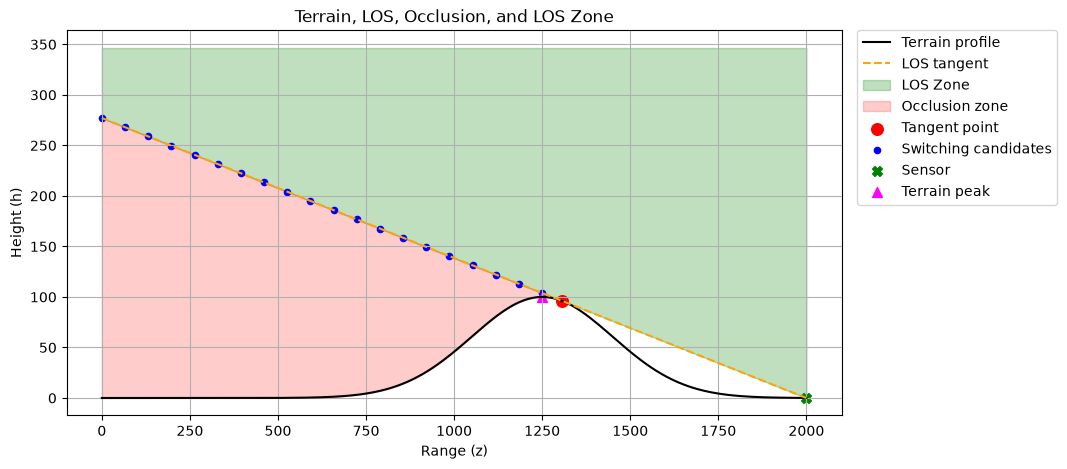

<Figure size 640x480 with 0 Axes>

In [3]:
# STEP 2 PLOT
import matplotlib.pyplot as plt
import numpy as np

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']
occlusion_mask = np.array(terrain_data['occlusion_mask'], dtype=bool)
los_mask = np.array(terrain_data['los_mask'], dtype=bool)
switching_candidates = np.array(terrain_data['switching_candidates'])

z_sensor = terrain_data['params']['Z_SENSOR']
los_plot_mask = z_grid <= z_sensor
z_line = z_grid[los_plot_mask]
los_line = LOS['slope'] * z_line + LOS['intercept']

y_top = max(h_terrain_vals.max(), los_line.max()) * 1.25
los_line_all = LOS['slope'] * z_grid + LOS['intercept']
los_zone_boundary = np.maximum(h_terrain_vals, los_line_all)

plt.figure(figsize=(10, 5))
plt.plot(z_grid, h_terrain_vals, label='Terrain profile', color='black')
plt.plot(z_line, los_line, '--', label='LOS tangent', color='orange')

# LOS Zone: visible region above LOS boundary and terrain
plt.fill_between(z_grid, los_zone_boundary, y_top, color='green', alpha=0.25, label='LOS Zone')

# Occlusion Zone: terrain < h < LOS line, z < z_tangent
occluded_z = z_grid[occlusion_mask]
occluded_h = h_terrain_vals[occlusion_mask]
h_los_line_occluded = LOS['slope'] * occluded_z + LOS['intercept']
if occluded_z.size > 0:
    plt.fill_between(occluded_z, occluded_h, h_los_line_occluded, color='red', alpha=0.2, label='Occlusion zone')

plt.scatter([LOS['z_tangent']], [LOS['h_tangent']], c='red', s=70, marker='o', label='Tangent point')

plt.scatter(switching_candidates[:, 0], switching_candidates[:, 1], c='blue', s=20, label='Switching candidates')
plt.scatter([terrain_data['params']['Z_SENSOR']], [terrain_data['params']['H_SENSOR']], c='green', s=50, marker='X', label='Sensor')
plt.scatter([terrain_data['params']['Z_RIDGE']], [terrain_data['params']['H_RIDGE']], c='magenta', s=50, marker='^', label='Terrain peak')

plt.xlabel('Range (z)')
plt.ylabel('Height (h)')
plt.title('Terrain, LOS, Occlusion, and LOS Zone')
plt.grid(True)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()
plt.tight_layout()

## Step 3: Sensor Detection Module

This section implements sensor detection models for acoustic, Doppler radar, and RCS radar channels. Detection rates are computed over a (z, h) grid with representative velocity and glide angle values, accounting for occlusion.


In [4]:
# STEP 3 COMPUTE
import numpy as np

def lambda_acoustic(z, h, v, z_sensor, h_sensor, params):
    """
    Acoustic detection rate. Powered phase only.
    λ_ac = LAM_ACOUSTIC * v^N_ACOUSTIC / max(r, R_FLOOR)^2
    r = distance from (z, h) to (z_sensor, h_sensor)
    """
    r = np.sqrt((z - z_sensor)**2 + (h - h_sensor)**2)
    r_eff = np.maximum(r, params['R_FLOOR'])
    lam_ac = params['LAM_ACOUSTIC'] * (v ** params['N_ACOUSTIC']) / (r_eff ** 2)
    return float(lam_ac)


def lambda_doppler(z, h, v, gamma, z_sensor, h_sensor, params):
    """
    Doppler radar detection rate. Both phases.
    λ_dop = LAM_DOPPLER * v_r^2 / max(r, R_FLOOR)^4
    v_r = v * cos(angle between velocity vector and LOS to sensor)
    gamma: glide angle in degrees (negative downward)
    """
    # LOS vector from aircraft to sensor
    dz = z_sensor - z
    dh = h_sensor - h
    r = np.sqrt(dz**2 + dh**2)
    
    if r < 1e-6:
        return 0.0
    
    # Velocity vector: v at angle gamma
    gamma_rad = np.radians(gamma)
    v_z = v * np.cos(gamma_rad)
    v_h = v * np.sin(gamma_rad)  # positive upward
    
    # LOS unit vector
    los_z = dz / r
    los_h = dh / r
    
    # Radial velocity component
    v_r = v_z * los_z + v_h * los_h
    
    r_eff = np.maximum(r, params['R_FLOOR'])
    lam_dop = params['LAM_DOPPLER'] * (v_r ** 2) / (r_eff ** 4)
    return float(lam_dop)


def lambda_rcs(z, h, gamma, z_sensor, h_sensor, params):
    """
    RCS radar detection rate. Both phases.
    λ_rcs = LAM_RCS * SIGMA0 * cos^2(gamma - gamma_min) / max(r, R_FLOOR)^4
    """
    r = np.sqrt((z - z_sensor)**2 + (h - h_sensor)**2)
    r_eff = np.maximum(r, params['R_FLOOR'])
    
    gamma_min = params['GAMMA_MIN']
    angle_diff = gamma - gamma_min
    cos_term = np.cos(np.radians(angle_diff))
    
    lam_rcs = params['LAM_RCS'] * params['SIGMA0'] * (cos_term ** 2) / (r_eff ** 4)
    return float(lam_rcs)


def lambda_total(z, h, v, gamma, sensor_list, phase, LOS, params):
    """
    Fused detection rate over all sensors and channels.
    phase: 'powered' or 'glide'
    sensor_list: list of (z_s, h_s) tuples
    LOS: dict with 'z_tangent' key for occlusion check
    Returns scalar λ_total (sum over sensors and available channels).
    """
    lam = 0.0
    
    # Occlusion check: if z < z_tangent, fully occluded
    if z < LOS['z_tangent']:
        return 0.0
    
    for z_s, h_s in sensor_list:
        # Acoustic (powered phase only)
        if phase == 'powered':
            lam += lambda_acoustic(z, h, v, z_s, h_s, params)
        
        # Doppler and RCS (both phases)
        lam += lambda_doppler(z, h, v, gamma, z_s, h_s, params)
        lam += lambda_rcs(z, h, gamma, z_s, h_s, params)
    
    return float(lam)


# Evaluation on (z, h) grid
z_max = max(params['Z_SENSOR'], params['Z_RIDGE'])
z_grid = np.linspace(0.0, z_max, 50)
h_grid = np.linspace(0.0, params['H_RIDGE'] * 2.0, 50)

# Representative flight parameters
v_powered = 20.0  # m/s, powered phase
v_glide = 15.0    # m/s, glide phase
gamma_powered = -30.0  # degrees
gamma_glide = -45.0    # degrees

# Sensor list (single sensor for now, but scalable)
sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]

# Create 2D grids for mapping
Z_grid, H_grid = np.meshgrid(z_grid, h_grid)

# Compute detection maps
lambda_acoustic_map = np.zeros_like(Z_grid)
lambda_doppler_map = np.zeros_like(Z_grid)
lambda_rcs_map = np.zeros_like(Z_grid)
lambda_total_powered_map = np.zeros_like(Z_grid)
lambda_total_glide_map = np.zeros_like(Z_grid)
occlusion_mask_2d = np.zeros_like(Z_grid, dtype=bool)

for i in range(len(h_grid)):
    for j in range(len(z_grid)):
        z, h = Z_grid[i, j], H_grid[i, j]
        
        # Acoustic (powered only)
        lambda_acoustic_map[i, j] = lambda_acoustic(z, h, v_powered, 
                                                     params['Z_SENSOR'], params['H_SENSOR'], params)
        
        # Doppler and RCS
        lambda_doppler_map[i, j] = lambda_doppler(z, h, v_powered, gamma_powered,
                                                  params['Z_SENSOR'], params['H_SENSOR'], params)
        lambda_rcs_map[i, j] = lambda_rcs(z, h, gamma_powered,
                                          params['Z_SENSOR'], params['H_SENSOR'], params)
        
        # Total detection rates
        lambda_total_powered_map[i, j] = lambda_total(z, h, v_powered, gamma_powered, 
                                                      sensor_list, 'powered', LOS, params)
        lambda_total_glide_map[i, j] = lambda_total(z, h, v_glide, gamma_glide,
                                                    sensor_list, 'glide', LOS, params)
        
        # Occlusion mask for 2D grid
        occlusion_mask_2d[i, j] = z < LOS['z_tangent']

sensor_data = {
    "params": params,
    "z_grid": z_grid.tolist(),
    "h_grid": h_grid.tolist(),
    "lambda_acoustic_map": lambda_acoustic_map.tolist(),
    "lambda_doppler_map": lambda_doppler_map.tolist(),
    "lambda_rcs_map": lambda_rcs_map.tolist(),
    "lambda_total_powered_map": lambda_total_powered_map.tolist(),
    "lambda_total_glide_map": lambda_total_glide_map.tolist(),
    "occlusion_mask_2d": occlusion_mask_2d.tolist(),
    "LOS": LOS,
}

sensor_path = os.path.join(DATA_DIR, 'sensors.json')
with open(sensor_path, 'w') as f:
    json.dump(sensor_data, f, indent=2)

print('Sensor data saved to', sensor_path)

Sensor data saved to d:\git\git_research\glider_hybrid_control\p1b\data\sensors.json


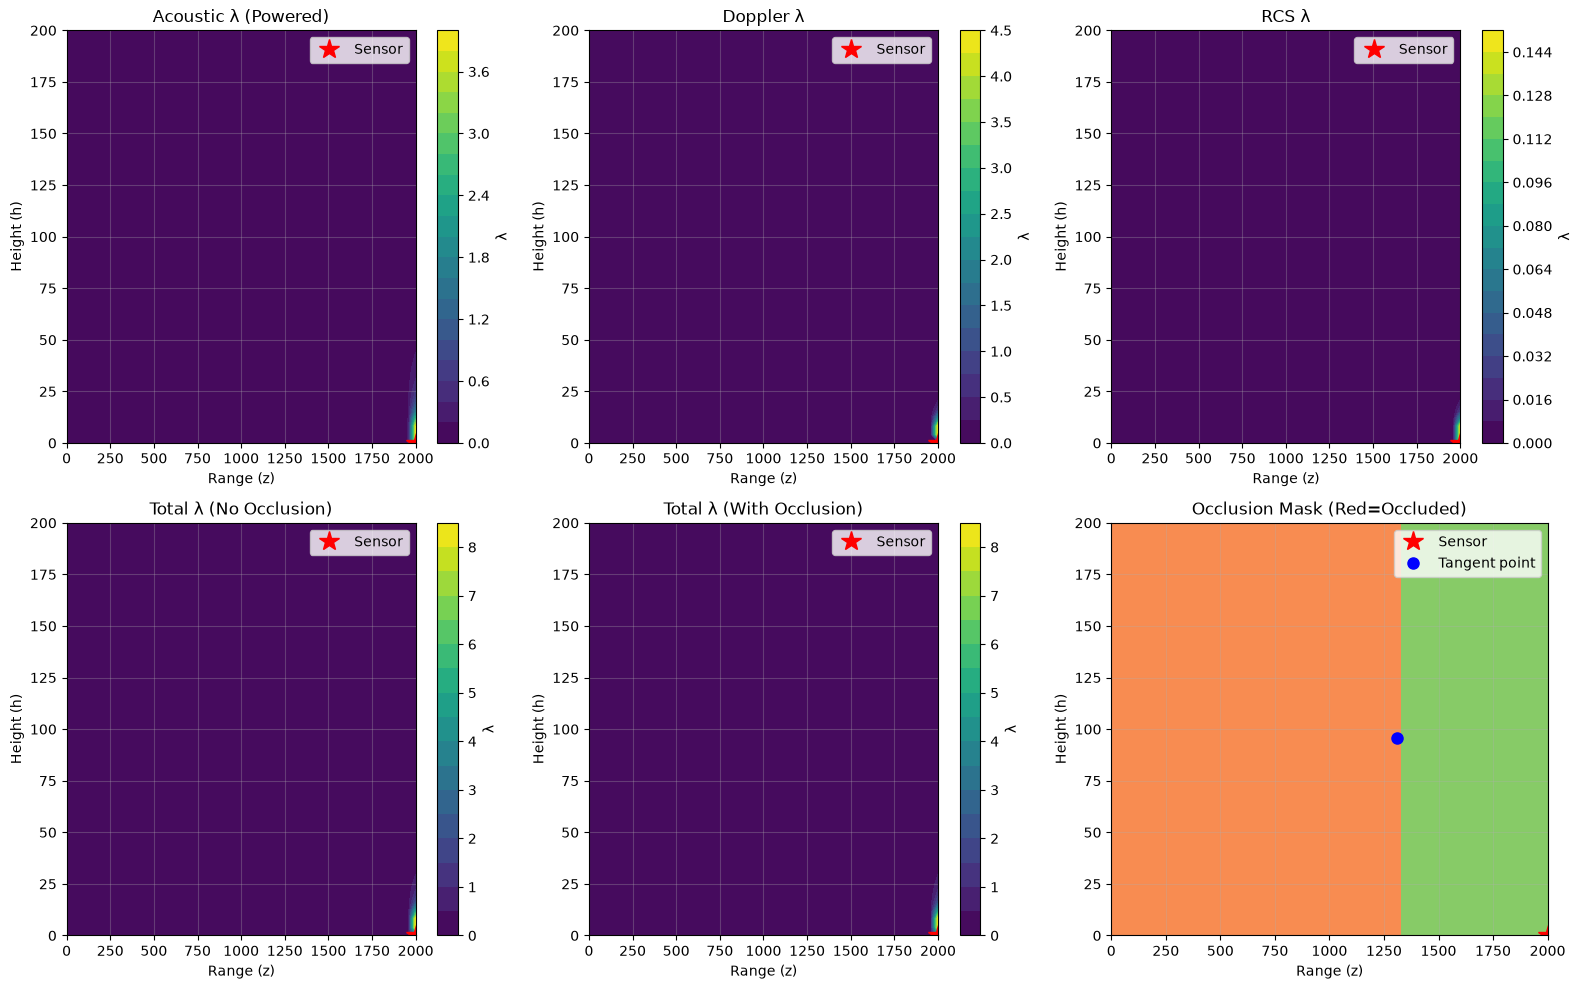

Sensor position: z=2000.0, h=0.0
Max acoustic λ: 3.8400e+00
Max doppler λ: 4.5000e+00
Max RCS λ: 1.5000e-01
Max total λ (no occlusion): 8.4900e+00
Max total λ (with occlusion): 8.4900e+00


In [5]:
# STEP 3 PLOT
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
import numpy as np

sensor_path = os.path.join(DATA_DIR, 'sensors.json')
with open(sensor_path, 'r') as f:
    sensor_data = json.load(f)

z_grid = np.array(sensor_data['z_grid'])
h_grid = np.array(sensor_data['h_grid'])
Z_grid, H_grid = np.meshgrid(z_grid, h_grid)

lambda_acoustic = np.array(sensor_data['lambda_acoustic_map'])
lambda_doppler = np.array(sensor_data['lambda_doppler_map'])
lambda_rcs = np.array(sensor_data['lambda_rcs_map'])
lambda_total_powered = np.array(sensor_data['lambda_total_powered_map'])
occlusion_mask_2d = np.array(sensor_data['occlusion_mask_2d'], dtype=bool)

LOS = sensor_data['LOS']
z_sensor = sensor_data['params']['Z_SENSOR']
h_sensor = sensor_data['params']['H_SENSOR']

# Apply occlusion mask: set detection rate to 0 in occlusion zone
lambda_total_powered_occluded = lambda_total_powered.copy()
lambda_total_powered_occluded[occlusion_mask_2d] = 0.0

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Helper function to plot heatmap with sensor marker
def plot_detection_map(ax, data, title, z_grid, h_grid, z_sensor, h_sensor):
    im = ax.contourf(Z_grid, H_grid, data, levels=20, cmap='viridis')
    ax.plot([z_sensor], [h_sensor], 'r*', markersize=15, label='Sensor')
    ax.set_xlabel('Range (z)')
    ax.set_ylabel('Height (h)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('λ')
    return im

# Plot each detection channel
plot_detection_map(axes[0, 0], lambda_acoustic, 'Acoustic λ (Powered)', z_grid, h_grid, z_sensor, h_sensor)
plot_detection_map(axes[0, 1], lambda_doppler, 'Doppler λ', z_grid, h_grid, z_sensor, h_sensor)
plot_detection_map(axes[0, 2], lambda_rcs, 'RCS λ', z_grid, h_grid, z_sensor, h_sensor)

# Total detection rate before occlusion
plot_detection_map(axes[1, 0], lambda_total_powered, 'Total λ (No Occlusion)', z_grid, h_grid, z_sensor, h_sensor)

# Total detection rate after occlusion
plot_detection_map(axes[1, 1], lambda_total_powered_occluded, 'Total λ (With Occlusion)', z_grid, h_grid, z_sensor, h_sensor)

# Occlusion mask visualization
im_occ = axes[1, 2].contourf(Z_grid, H_grid, occlusion_mask_2d.astype(int), levels=[0, 0.5, 1], cmap='RdYlGn_r')
axes[1, 2].plot([z_sensor], [h_sensor], 'r*', markersize=15, label='Sensor')
axes[1, 2].plot([LOS['z_tangent']], [LOS['h_tangent']], 'bo', markersize=8, label='Tangent point')
axes[1, 2].set_xlabel('Range (z)')
axes[1, 2].set_ylabel('Height (h)')
axes[1, 2].set_title('Occlusion Mask (Red=Occluded)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print(f"Sensor position: z={z_sensor}, h={h_sensor}")
print(f"Max acoustic λ: {lambda_acoustic.max():.4e}")
print(f"Max doppler λ: {lambda_doppler.max():.4e}")
print(f"Max RCS λ: {lambda_rcs.max():.4e}")
print(f"Max total λ (no occlusion): {lambda_total_powered.max():.4e}")
print(f"Max total λ (with occlusion): {lambda_total_powered_occluded.max():.4e}")

## Step 4: Dynamics Module

In [6]:
# STEP 4 COMPUTE
import numpy as np

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

LOS = terrain_data['LOS']


def powered_trajectory(z_sw, h_sw, params):
    """
    Straight-line kinematics from (0, 0) to (z_sw, h_sw).
    Fixed speed V_LAUNCH, dt = DT_POW.
    Returns list of states: [(z, h, v, gamma), ...]
    """
    v = params['V_LAUNCH']
    dt = params['DT_POW']
    distance = np.sqrt(z_sw**2 + h_sw**2)
    if distance <= 0.0:
        return [(0.0, 0.0, float(v), 0.0)]

    n_steps = max(1, int(np.ceil(distance / (v * dt))))
    z_values = np.linspace(0.0, z_sw, n_steps + 1)
    h_values = np.linspace(0.0, h_sw, n_steps + 1)
    gamma = np.arctan2(h_sw, z_sw)

    return [
        (float(z), float(h), float(v), float(gamma))
        for z, h in zip(z_values, h_values)
    ]


def glider_dynamics(state, gamma_cmd, params):
    """
    Point mass glide dynamics. No thrust, drag only.
    state: (z, h, v, gamma)
    gamma_cmd: commanded flight path angle (rad)
    Returns next state after DT_GLIDE.
    Replaceable interface — do not hardcode physics elsewhere.
    Uses RK4 integration.
    """
    def derivatives(s):
        z, h, v, gamma = s
        dz = v * np.cos(gamma_cmd)
        dh = v * np.sin(gamma_cmd)
        D = 0.5 * params['RHO'] * v**2 * params['CD'] * params['S']
        dv = -D / params['M']
        return np.array([dz, dh, dv, 0.0], dtype=float)

    dt = params['DT_GLIDE']
    s = np.array(state, dtype=float)

    k1 = derivatives(s)
    k2 = derivatives(s + 0.5 * dt * k1)
    k3 = derivatives(s + 0.5 * dt * k2)
    k4 = derivatives(s + dt * k3)

    s_next = s + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    s_next[3] = float(gamma_cmd)
    s_next[2] = max(s_next[2], 0.0)
    s_next[1] = max(s_next[1], 0.0)

    return (float(s_next[0]), float(s_next[1]), float(s_next[2]), float(s_next[3]))


z_goal = params['Z_GOAL']
h_goal = params['H_GOAL']

# Select switching points strictly on the LOS line and inside the occlusion zone.
z_candidates = np.linspace(0.1 * LOS['z_tangent'], 0.9 * LOS['z_tangent'], 3)

sample_trajectories = []
for idx, z_sw in enumerate(z_candidates):
    h_sw = float(LOS['slope'] * z_sw + LOS['intercept'])
    assert 0.0 < z_sw < LOS['z_tangent'], 'Switch point must remain inside occlusion zone'
    powered = powered_trajectory(z_sw, h_sw, params)

    # Use a constant glide flight path angle that aims from the switch point to the goal.
    gamma_cmd = float(np.arctan2(h_goal - h_sw, z_goal - z_sw))
    glide = []
    state = powered[-1]
    for _ in range(500):
        next_state = glider_dynamics(state, gamma_cmd, params)
        glide.append(next_state)
        if next_state[2] <= 0.0:
            break
        if next_state[0] >= z_goal:
            break
        state = next_state

    if len(glide) > 0 and glide[-1][0] < z_goal and glide[-1][1] > 0.0:
        glide.append((float(z_goal), 0.0, float(glide[-1][2]), float(gamma_cmd)))

    sample_trajectories.append({
        'z_sw': float(z_sw),
        'h_sw': float(h_sw),
        'powered': [[float(x) for x in s] for s in powered],
        'glide': [[float(x) for x in s] for s in glide],
    })

dynamics_data = {
    'params': params,
    'sample_trajectories': sample_trajectories,
}

with open(os.path.join(DATA_DIR, 'dynamics.json'), 'w') as f:
    json.dump(dynamics_data, f, indent=2)

print('Dynamics data saved to', os.path.join(DATA_DIR, 'dynamics.json'))

Dynamics data saved to d:\git\git_research\glider_hybrid_control\p1b\data\dynamics.json


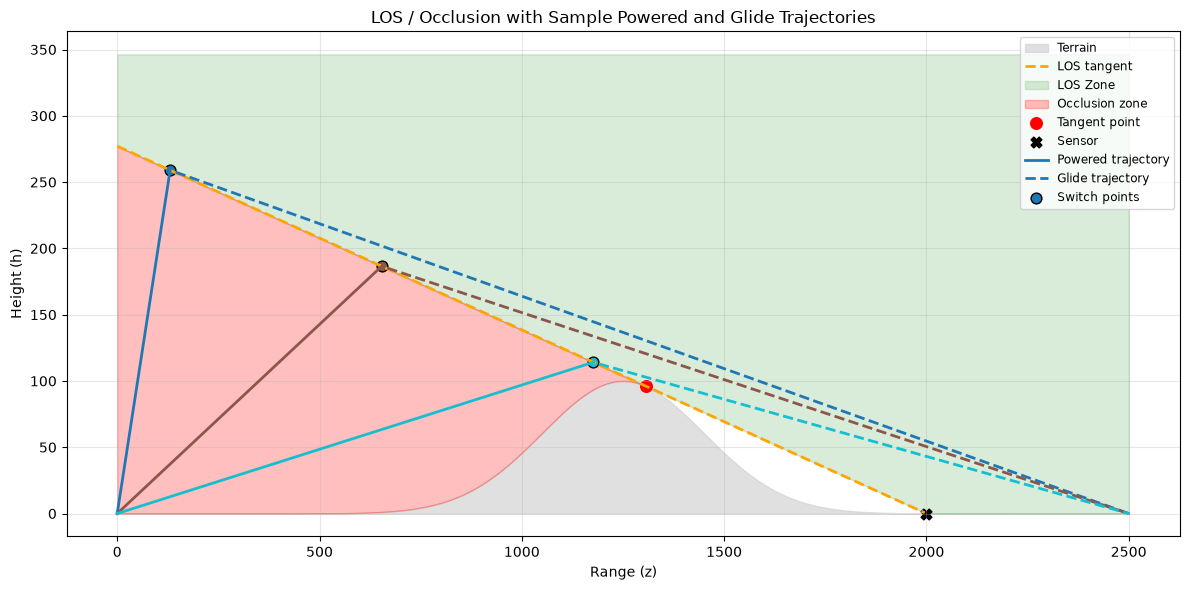

In [12]:
# STEP 4 PLOT
import matplotlib.pyplot as plt
import numpy as np

with open(os.path.join(DATA_DIR, 'terrain.json'), 'r') as f:
    terrain_data = json.load(f)
with open(os.path.join(DATA_DIR, 'dynamics.json'), 'r') as f:
    dynamics_data = json.load(f)

params_plot = terrain_data['params']
LOS = terrain_data['LOS']

# Terrain profile for background.
def h_terrain(z, params):
    z_ridge = params['Z_RIDGE']
    h_ridge = params['H_RIDGE']
    sigma = params['SIGMA_TERRAIN']
    return h_ridge * np.exp(-0.5 * ((z - z_ridge) / sigma) ** 2)

z_grid = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])

z_plot = np.linspace(0.0, max(params_plot['Z_SENSOR'], params_plot['Z_GOAL'], params_plot['Z_RIDGE']), 601)
h_plot = h_terrain(z_plot, params_plot)
los_mask_plot = z_plot <= params_plot['Z_SENSOR']
z_line = z_plot[los_mask_plot]
los_line = LOS['slope'] * z_line + LOS['intercept']

y_top = max(h_plot.max(), np.max(los_line)) * 1.25
los_line_all = LOS['slope'] * z_plot + LOS['intercept']
los_zone_boundary = np.maximum(h_plot, los_line_all)

plt.figure(figsize=(12, 6))
plt.fill_between(z_plot, 0.0, h_plot, color='lightgrey', alpha=0.7, label='Terrain')
plt.plot(z_line, los_line, '--', color='orange', linewidth=2, label='LOS tangent')
plt.fill_between(z_plot, los_zone_boundary, y_top, color='green', alpha=0.15, label='LOS Zone')

occlusion_mask = np.array(terrain_data['occlusion_mask'], dtype=bool)
occluded_z = z_grid[occlusion_mask]
occluded_h = h_terrain_vals[occlusion_mask]
h_los_line_occluded = LOS['slope'] * occluded_z + LOS['intercept']
if occluded_z.size > 0:
    plt.fill_between(occluded_z, occluded_h, h_los_line_occluded, color='red', alpha=0.25, label='Occlusion zone')

plt.scatter([LOS['z_tangent']], [LOS['h_tangent']], c='red', s=70, marker='o', label='Tangent point')
plt.scatter([params_plot['Z_SENSOR']], [params_plot['H_SENSOR']], c='black', s=60, marker='X', label='Sensor')

colors = plt.cm.tab10(np.linspace(0, 1, len(dynamics_data['sample_trajectories'])))
for idx, traj in enumerate(dynamics_data['sample_trajectories']):
    powered = np.array(traj['powered'])
    glide = np.array(traj['glide'])
    z_sw = traj['z_sw']
    h_sw = traj['h_sw']
    color = colors[idx]

    powered_label = 'Powered trajectory' if idx == 0 else '_nolegend_'
    glide_label = 'Glide trajectory' if idx == 0 else '_nolegend_'
    switch_label = 'Switch points' if idx == 0 else '_nolegend_'

    plt.plot(powered[:, 0], powered[:, 1], '-', linewidth=2, color=color, label=powered_label)
    if glide.size > 0:
        plt.plot(glide[:, 0], glide[:, 1], '--', linewidth=2, color=color, label=glide_label)
    plt.scatter([z_sw], [h_sw], s=60, c=[color], edgecolors='k', linewidths=1.0, marker='o', label=switch_label)

plt.xlabel('Range (z)')
plt.ylabel('Height (h)')
plt.title('LOS / Occlusion with Sample Powered and Glide Trajectories')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

## Next Steps

- Implement terrain computation and LOS checks.
- Implement sensor models and Poisson detection rates.
- Implement attacker dynamics and DP solver.
- Implement Stackelberg outer loop to optimize sensor placement.